In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize

CENTRAL_FREQUENCY = 2_252_500_000
C = 299792458
CLOCK_ERROR_RAW = 655

In [ ]:
data = {}
first_timestamp = 0

with open('raw_samples.csv', 'r') as infile:
    reader = csv.reader(infile)
    next(reader)
    firstdata = next(reader)
    first_timestamp = float(firstdata[0])
    freqshift = round(sum(float(x) for x in firstdata[1:])/len(firstdata[1:]), 3)
    data[0.0] = freqshift
    for row in reader:
        timestamp = float(row[0])
        freqshift = round(sum(float(x) for x in row[1:])/len(row[1:]), 3)
        data[timestamp-first_timestamp] = freqshift-CLOCK_ERROR_RAW

In [ ]:
def frequency_to_velocity(frequency_shift, signal_frequency=CENTRAL_FREQUENCY, v_medium=C):
    velocity = (frequency_shift / signal_frequency) * v_medium
    return velocity

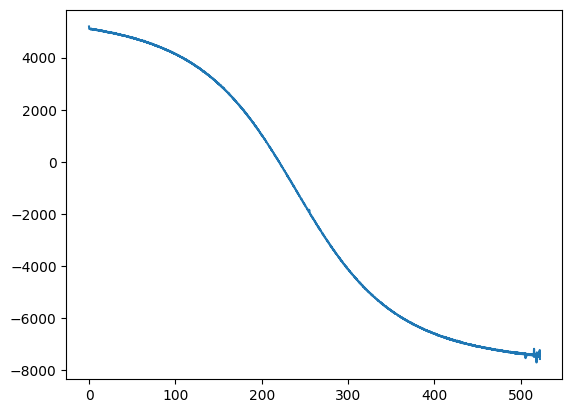

In [ ]:
x = np.array(list(data.keys()))
y = np.array([frequency_to_velocity(freq) for freq in data.values()])
plt.plot(x, y)
plt.show()